Initialize a single sensed component and plot 10 simulation steps

In [ ]:
from component_objects.component_weibull import WeibullComponent
from sensor_objects.diagnostic_sensors.binary_diagnostic_sensor import BinaryDiagnosticSensor
from sensor_objects.prognostic_sensors.PF_prognostic_sensor import PF_PrognosticSensor
from sensed_objects.sensed_comp import BaseSensedComponent

import numpy as np

# fix random seed
random_seed = 20
np.random.seed(random_seed)

# simulation parameters
comp_MTTF = 5
shape_parameter= 2.0
num_comps = 3                           # number of failure instances from distribution
num_diagnostic_sensors = 3              # number of diagnostic sensors used as evidence for prognosis
diagnostic_sensor_reliability = 0.5     # starting with 100% sensing accuracy

# create an individual component object
comp = WeibullComponent("Comp #1", 
                 MTTF = comp_MTTF, 
                 MTTR= 10, 
                 shape=shape_parameter)


# initialize three diagnostic sensors
diagnostic_sensors = [BinaryDiagnosticSensor(diagnostic_sensor_reliability) for _ in range(num_diagnostic_sensors)]

# initialize one prognostic sensors
prognostic_sensor = PF_PrognosticSensor(comp= comp, 
                                        sensors = diagnostic_sensors)

# add the diagnostic and prognostic sensors to a component 
sensed_comp = BaseSensedComponent(comp, 
                                   diagnostic_sensors, 
                                   prognostic_sensor)
sensed_comp.simulate(10)
sensed_comp.plot_history( plot_diagnostics = True)

TypeError: BinaryDiagnosticSensor.diagnose() missing 2 required positional arguments: 'true_state' and 't'

In [ ]:
from component_objects.component_weibull import WeibullComponent
from sensor_objects.diagnostic_sensors.binary_diagnostic_sensor import BinaryDiagnosticSensor
from sensor_objects.prognostic_sensors.PF_prognostic_sensor import PF_PrognosticSensor
from sensed_objects.sensed_comp import BaseSensedComponent

import numpy as np

# fix random seed
random_seed = 20
np.random.seed(random_seed)

# simulation parameters
comp_MTTF = 5
shape_parameter= 2.0
num_comps = 3                           # number of failure instances from distribution
num_diagnostic_sensors = 3              # number of diagnostic sensors used as evidence for prognosis
diagnostic_sensor_reliability = 0.5     # starting with 100% sensing accuracy

# create an individual component object
comp = WeibullComponent("Comp #1", 
                 MTTF = comp_MTTF, 
                 MTTR= 10, 
                 shape=shape_parameter)


# initialize three diagnostic sensors
diagnostic_sensors = [BinaryDiagnosticSensor(diagnostic_sensor_reliability) for _ in range(num_diagnostic_sensors)]

# initialize one prognostic sensors
prognostic_sensor = PF_PrognosticSensor(comp= comp, 
                                        sensors = diagnostic_sensors)

# add the diagnostic and prognostic sensors to a component 
sensed_comp = BaseSensedComponent(comp, 
                                   diagnostic_sensors, 
                                   prognostic_sensor)
sensed_comp.simulate(10)
sensed_comp.plot_history( plot_diagnostics = True)

Initializing three components and ploting relevant parameters

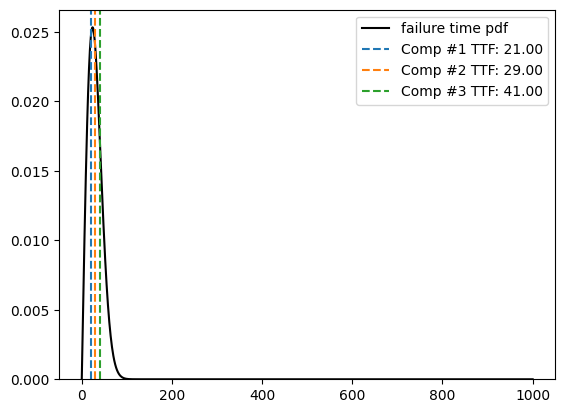

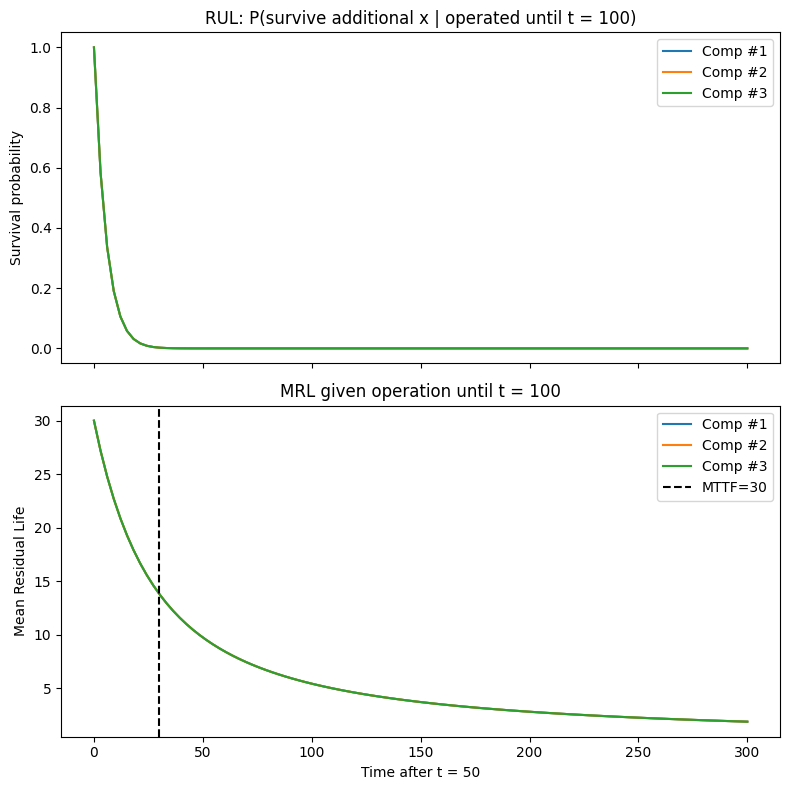

In [1]:
from component_objects.component_weibull import WeibullComponent

import numpy as np
import matplotlib.pyplot as plt

# fix random seed
random_seed = 26
np.random.seed(random_seed)

# simulation parameters
comp_MTTF = 30
shape_parameter= 2.0
num_comps = 3                           # number of failure instances from distribution
num_diagnostic_sensors = 3              # number of diagnostic sensors used as evidence for prognosis
diagnostic_sensor_reliability = 0.8     # starting with 100% sensing accuracy

# initialize n components with the same weibull distribution
comps = [WeibullComponent(f"Comp #{i+1}", MTTF = comp_MTTF, MTTR= 10, shape=shape_parameter) for i in range(3)]

# plot the general component faiure distribution and highlight each failure instances
t_array = np.linspace(0, 1000, 1000)
plt.figure()
ax = comps[0].plot_failure_pdf(t_array) # plot the first comp with the distribution
for i in range(len(comps)-1):
    comps[i+1].plot_time_to_fail()  # add the failure instance of the other comps
plt.show()

# plot statistical RUL versus weibull estimate RUL for each comp
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

future_time_array = np.linspace(0, 300, 100)
RULs = np.empty((num_comps, len(future_time_array)))
MRLs = np.empty_like(RULs)

current_time = 100   # assuming the comps have already operated up until this time

for i, comp in enumerate(comps):

    # --- RUL curve ---
    RULs[i, :] = comp.RUL(current_time, future_time_array)
    axes[0].plot(
        future_time_array,
        RULs[i],
        label=comp.name
    )

    # --- MRL curve ---
    # for j, dt in enumerate(future_time_array):
    MRLs[i,:] = comp.MRL(future_time_array)
    axes[1].plot(
        future_time_array,
        MRLs[i],
        label=comp.name
    )
plt.axvline(comp_MTTF, linestyle="--", color='k', label=f"MTTF={comp_MTTF}")

# --- Axis labels ---
axes[0].set_ylabel("Survival probability")
axes[1].set_ylabel("Mean Residual Life")
axes[1].set_xlabel("Time after t = 50")

# --- Titles ---
axes[0].set_title(f"RUL: P(survive additional x | operated until t = {current_time})")
axes[1].set_title(f"MRL given operation until t = {current_time}")

# --- Legends ---
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

In [1]:
from sensor_objects.diagnostic_sensors.binary_diagnostic_sensor import BinaryDiagnosticSensor
from sensor_objects.prognostic_sensors.PF_prognostic_sensor import PF_PrognosticSensor
from sensed_objects.sensed_comp import BaseSensedComponent

# initialize diagnosis sensors for each component which all have the same sensing reliability
diagnostic_sensors = [None for _ in range(num_comps)]
for i in range(num_comps):
    diagnostic_sensors[i] = [BinaryDiagnosticSensor(diagnostic_sensor_reliability) for _ in range(num_diagnostic_sensors)]

# initialize one prognosis sensor per component
prognostic_sensors = [PF_PrognosticSensor(comp=comps[i], sensors = diagnostic_sensors[i]) for i in range(num_comps)]

# pair diagnostic sensors and one prognosis sensor to the components
sensed_comps = [BaseSensedComponent(comps[i], diagnostic_sensors[i], prognostic_sensors[i]) for i in range(len(comps))]
# print(sensed_comps[0])

# step all objects through T timesteps
T = 150
# for i in range(num_comps):
#     pass
sensed_comps[0].simulate(T, dt=1)
sensed_comps[0].plot_history()

NameError: name 'num_comps' is not defined